# <a>Projeto Análise Exploratória de Dados ENEM 2019<a/>

## <a>Objeto de Estudo<a/>
    

Neste estudo vamos usar dados do ENEM 2019 como base, vamos investigar se variáveis como dados demográficos, indicadores sociais, nível de escolaridade dos pais e outras informações têm relação com o desempenho dos candidatos. Muitas descobertas e respostas podem surgir apenas com uma análise exploratória dos dados.
Analisar detalhadamente os dados dos participantes pode gerar insights valiosos para a educação no Brasil. As notas obtidas no exame permitem o acesso a programas e garantir financiamento estudantil por meio de programas governamentais. Além disso, os resultados do ENEM contribuem para a criação de estudos e indicadores educacionais.
    
Obs: Os dados serão retirados do site do [INEP](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem).

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
from string import ascii_uppercase
from matplotlib.lines import Line2D
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df_enem = pd.read_parquet('./enem_2019.parquet')
df_enem.shape   

(5095270, 136)

In [3]:
df_enem.head()

,NU_INSCRICAO,NU_ANO,CO_MUNICIPIO_RESIDENCIA,NO_MUNICIPIO_RESIDENCIA,CO_UF_RESIDENCIA,SG_UF_RESIDENCIA,NU_IDADE,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,CO_MUNICIPIO_NASCIMENTO,NO_MUNICIPIO_NASCIMENTO,CO_UF_NASCIMENTO,SG_UF_NASCIMENTO,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,TP_ENSINO,IN_TREINEIRO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,IN_BAIXA_VISAO,IN_CEGUEIRA,IN_SURDEZ,IN_DEFICIENCIA_AUDITIVA,IN_SURDO_CEGUEIRA,IN_DEFICIENCIA_FISICA,IN_DEFICIENCIA_MENTAL,IN_DEFICIT_ATENCAO,IN_DISLEXIA,IN_DISCALCULIA,IN_AUTISMO,IN_VISAO_MONOCULAR,IN_OUTRA_DEF,IN_GESTANTE,IN_LACTANTE,IN_IDOSO,IN_ESTUDA_CLASSE_HOSPITALAR,IN_SEM_RECURSO,IN_BRAILLE,IN_AMPLIADA_24,IN_AMPLIADA_18,IN_LEDOR,IN_ACESSO,IN_TRANSCRICAO,IN_LIBRAS,IN_TEMPO_ADICIONAL,IN_LEITURA_LABIAL,IN_MESA_CADEIRA_RODAS,IN_MESA_CADEIRA_SEPARADA,IN_APOIO_PERNA,IN_GUIA_INTERPRETE,IN_COMPUTADOR,IN_CADEIRA_ESPECIAL,IN_CADEIRA_CANHOTO,IN_CADEIRA_ACOLCHOADA,IN_PROVA_DEITADO,IN_MOBILIARIO_OBESO,IN_LAMINA_OVERLAY,IN_PROTETOR_AURICULAR,IN_MEDIDOR_GLICOSE,IN_MAQUINA_BRAILE,IN_SOROBAN,IN_MARCA_PASSO,IN_SONDA,IN_MEDICAMENTOS,IN_SALA_INDIVIDUAL,IN_SALA_ESPECIAL,IN_SALA_ACOMPANHANTE,IN_MOBILIARIO_ESPECIFICO,IN_MATERIAL_ESPECIFICO,IN_NOME_SOCIAL,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,190001595656,2019,3552205,Sorocaba,35,SP,36.00,M,1,3,1,2914802.00,Itabuna,29.00,BA,1,11,1,NaN,0,NaN,NaN,None,NaN,None,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3552205,Sorocaba,35,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,A,2,A,A,B,C,A,A,B,A,A,A,A,A,A,A,A,A,C,A,C,B
1,190001421546,2019,2910800,Feira de Santana,29,BA,23.00,M,1,1,1,2910800.00,Feira de Santana,29.00,BA,1,5,1,1.00,0,NaN,NaN,None,NaN,None,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2910800,Feira de Santana,29,BA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,E,B,B,4,C,A,B,C,A,A,B,A,A,A,A,A,A,B,A,A,E,A,A,B
2,190001133210,2019,2304400,Fortaleza,23,CE,39.00,F,1,3,1,2304400.00,Fortaleza,23.00,CE,1,13,1,1.00,0,NaN,NaN,None,NaN,None,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2304400,Fortaleza,23,CE,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,1,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,C,2,B,A,B,B,A,A,B,A,A,A,A,A,A,B,A,A,C,A,A,B
3,190001199383,2019,1721000,Palmas,17,TO,25.00,F,1,1,1,1721000.00,Palmas,17.00,TO,1,4,1,NaN,0,NaN,NaN,None,NaN,None,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1721000,Palmas,17,TO,1,1,1,1,504.00,510.00,513.00,516.00,483.80,503.60,537.30,392.00,BACCEEBEECDBEDDAEECDEDEADEBBCDBCAACADEEACCBBD,AECEDADAABAADBAADAEBACBAECCDAEADCDBBECCEDABCD,99999AAABEBBCCBDCAEECADBACAADAECCCDCCBAEBDEEEA...,DDBBBBCDCCDCAECCBBECDAEBADCD..CABCCECAEBDBBDA,1,BEEAAEBEEBADEADDADAEABCEDDDBCBCBCCACBCDADCCEB,EEBCEEDBADBBCBABCCADCEBACDBBACCACACBEADBBADCB,ADBBEDCABAABBCBCDAAECDDDBAAAECADECDCEBDEEAECBD...,BEDEEEAADBEBACABCDBABECECACADCBDCCEDCDABECDDD,1.00,120.00,120.00,120.00,100.00,0.00,460.00,C,E,B,D,4,E,A,C,C,A,B,B,A,B,A,A,A,A,C,A,B,D,A,B,B
4,190001237802,2019,3118601,Contagem,31,MG,22.00,F,1,1,1,3118601.00,C

In [4]:
# Validando dados
len(df_enem['NU_INSCRICAO'].unique())

5095270

### <a> Colunas relevantes </a>
- NU_INSCRICAO - Número de inscrição (Transformar em  uma Key primária mais palatável)
- TP_FAIXA_ETARIA - Faixa etária em que o candidato de encaixa
- NU_IDADE - Idade exata em que o cadidato realizou a prova
- TP_SEXO - Gênero do candidato
- TP_COR_RACA - Cor/Raça que o candidato declarou ter
- TP_ESCOLA - Tipo de escola em que o candidato frequentou durante seu ensino médio
- TP_PRESENCA_CN - Presença na prova objetiva de Ciências da Natureza
- TP_PRESENCA_CH - Presença na prova objetiva de Ciências Humanas
- TP_PRESENCA_LC - Presença na prova objetiva de Linguagens e Códigos
- TP_PRESENCA_MT - Presença na prova objetiva de Matemática
- NU_NOTA_CN -  Nota da prova de Ciências da Natureza
- NU_NOTA_CH - Nota da prova de Ciências Humanas
- NU_NOTA_LC - Nota da prova de Linguagens e Códigos
- NU_NOTA_MT - Nota da prova de Matemática
- TP_STATUS_REDACAO - Situação da redação do participante
- NU_NOTA_REDACAO - Nota da prova de redação
- Q001 - Até que série seu pai, ou o homem responsável por você, estudou?
- Q002 - Até que série sua mãe, ou a mulher responsável por você, estudou?
- Q006 - Renda mensal da família do candidato
- Q024 - O candidato possui computador em casa?
- Q025 - O candidato tem acesso à internet?
- Todas as colunas que identificam algum tipo de deficiencia que o candidato possa ter, necessitando assim de auxilio especial para realizar a prova. As colunas são: IN_BAIXA_VISAO, IN_CEGUEIRA, IN_SURDEZ, IN_DEFICIENCIA_AUDITIVA, IN_SURDO_CEGUEIRA, IN_DEFICIENCIA_FISICA, IN_DEFICIENCIA_MENTAL, IN_DEFICIT_ATENCAO, IN_DISLEXIA, IN_DISCALCULIA, IN_AUTISMO, IN_VISAO_MONOCULAR e IN_OUTRA_DEF

In [5]:
colunas_relevantes = ['NU_INSCRICAO', 'TP_FAIXA_ETARIA', 'NU_IDADE', 'TP_SEXO', 'TP_COR_RACA', 
                      'TP_ESCOLA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 
                      'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
                      'TP_STATUS_REDACAO', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q006', 'Q024', 'Q025', 
                      'IN_BAIXA_VISAO', 'IN_CEGUEIRA', 'IN_SURDEZ', 'IN_DEFICIENCIA_AUDITIVA',
                      'IN_SURDO_CEGUEIRA', 'IN_DEFICIENCIA_FISICA', 'IN_DEFICIENCIA_MENTAL',
                      'IN_DEFICIT_ATENCAO', 'IN_DISLEXIA', 'IN_DISCALCULIA', 'IN_AUTISMO',
                      'IN_VISAO_MONOCULAR', 'IN_OUTRA_DEF'
                     ]
colunas_remover = [coluna for coluna in df_enem.columns if coluna not in colunas_relevantes]

df_enem = df_enem.drop(colunas_remover, axis = 1)
df_enem.head()

,NU_INSCRICAO,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_BAIXA_VISAO,IN_CEGUEIRA,IN_SURDEZ,IN_DEFICIENCIA_AUDITIVA,IN_SURDO_CEGUEIRA,IN_DEFICIENCIA_FISICA,IN_DEFICIENCIA_MENTAL,IN_DEFICIT_ATENCAO,IN_DISLEXIA,IN_DISCALCULIA,IN_AUTISMO,IN_VISAO_MONOCULAR,IN_OUTRA_DEF,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025
0,190001595656,36.00,M,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,C,B
1,190001421546,23.00,M,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,C,E,C,A,B
2,190001133210,39.00,F,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,A,B
3,190001199383,25.00,F,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,483.80,503.60,537.30,392.00,1.00,460.00,C,E,E,B,B
4,190001237802,22.00,F,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,513.60,575.50,570.70,677.00,1.00,860.00,E,E,G,B,B


In [6]:
df_enem.shape

(5095270, 33)

In [7]:
colunas_atendimento_especial = ['IN_BAIXA_VISAO', 'IN_CEGUEIRA', 'IN_SURDEZ', 'IN_DEFICIENCIA_AUDITIVA',
                      'IN_SURDO_CEGUEIRA', 'IN_DEFICIENCIA_FISICA', 'IN_DEFICIENCIA_MENTAL',
                      'IN_DEFICIT_ATENCAO', 'IN_DISLEXIA', 'IN_DISCALCULIA', 'IN_AUTISMO',
                      'IN_VISAO_MONOCULAR', 'IN_OUTRA_DEF']
df_enem['atendimento_especializado'] = df_enem[colunas_atendimento_especial].any(axis = 1)
df_enem.head()


,NU_INSCRICAO,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_BAIXA_VISAO,IN_CEGUEIRA,IN_SURDEZ,IN_DEFICIENCIA_AUDITIVA,IN_SURDO_CEGUEIRA,IN_DEFICIENCIA_FISICA,IN_DEFICIENCIA_MENTAL,IN_DEFICIT_ATENCAO,IN_DISLEXIA,IN_DISCALCULIA,IN_AUTISMO,IN_VISAO_MONOCULAR,IN_OUTRA_DEF,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado
0,190001595656,36.00,M,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,C,B,False
1,190001421546,23.00,M,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,C,E,C,A,B,False
2,190001133210,39.00,F,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,A,B,False
3,190001199383,25.00,F,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,483.80,503.60,537.30,392.00,1.00,460.00,C,E,E,B,B,False
4,190001237802,22.00,F,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,513.60,575.50,570.70,677.00,1.00,860.00,E,E,G,B,B,False


In [8]:
df_enem = df_enem.drop(colunas_atendimento_especial, axis = 1)
df_enem.head()

,NU_INSCRICAO,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado
0,190001595656,36.00,M,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,C,B,False
1,190001421546,23.00,M,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,C,E,C,A,B,False
2,190001133210,39.00,F,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,A,B,False
3,190001199383,25.00,F,1,1,1,1,1,1,483.80,503.60,537.30,392.00,1.00,460.00,C,E,E,B,B,False
4,190001237802,22.00,F,1,1,1,1,1,1,513.60,575.50,570.70,677.00,1.00,860.00,E,E,G,B,B,False


In [9]:
df_enem.shape

(5095270, 21)

In [10]:
colunas_presenca_provas = ['TP_PRESENCA_CN', 
                           'TP_PRESENCA_CH', 
                           'TP_PRESENCA_LC', 
                           'TP_PRESENCA_MT']
df_enem['prova_objetiva_valida'] = (df_enem[colunas_presenca_provas] == 1).all(axis=1)
df_enem.head()

,NU_INSCRICAO,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado,prova_objetiva_valida
0,190001595656,36.00,M,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,C,B,False,False
1,190001421546,23.00,M,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,C,E,C,A,B,False,False
2,190001133210,39.00,F,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,A,B,False,False
3,190001199383,25.00,F,1,1,1,1,1,1,483.80,503.60,537.30,392.00,1.00,460.00,C,E,E,B,B,False,True
4,190001237802,22.00,F,1,1,1,1,1,1,513.60,575.50,570.70,677.00,1.00,860.00,E,E,G,B,B,False,True


In [11]:
df_enem['prova_objetiva_valida'].value_counts(normalize = True) * 100

prova_objetiva_valida
True    72.66
False   27.34
Name: proportion, dtype: float64

In [12]:
'''
1 Sem problemas
2 Anulada
3 Cópia Texto Motivador
4 Em Branco
6 Fuga ao tema
7 Não atendimento ao tipo textual
8 Texto insuficiente
9 Parte desconectada

'''
df_enem['TP_STATUS_REDACAO'].value_counts(normalize = True) * 100

TP_STATUS_REDACAO
1.00   96.34
4.00    1.45
6.00    1.04
3.00    0.59
8.00    0.22
2.00    0.14
9.00    0.12
7.00    0.10
Name: proportion, dtype: float64

In [13]:
df_enem['prova_redacao_valida'] = (df_enem['TP_STATUS_REDACAO'] == 1)
df_enem.head()

,NU_INSCRICAO,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado,prova_objetiva_valida,prova_redacao_valida
0,190001595656,36.00,M,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,C,B,False,False,False
1,190001421546,23.00,M,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,C,E,C,A,B,False,False,False
2,190001133210,39.00,F,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,A,B,False,False,False
3,190001199383,25.00,F,1,1,1,1,1,1,483.80,503.60,537.30,392.00,1.00,460.00,C,E,E,B,B,False,True,True
4,190001237802,22.00,F,1,1,1,1,1,1,513.60,575.50,570.70,677.00,1.00,860.00,E,E,G,B,B,False,True,True


In [14]:
df_enem['prova_valida'] = df_enem['prova_objetiva_valida'] & df_enem['prova_redacao_valida']
df_enem.head()

,NU_INSCRICAO,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado,prova_objetiva_valida,prova_redacao_valida,prova_valida
0,190001595656,36.00,M,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,B,B,A,C,B,False,False,False,False
1,190001421546,23.00,M,1,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,C,E,C,A,B,False,False,False,False
2,190001133210,39.00,F,3,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,E,E,B,A,B,False,False,False,False
3,190001199383,25.00,F,1,1,1,1,1,1,483.80,503.60,537.30,392.00,1.00,460.00,C,E,E,B,B,False,True,True,True
4,190001237802,22.00,F,1,1,1,1,1,1,513.60,575.50,570.70,677.00,1.00,860.00,E,E,G,B,B,False,True,True,True


In [15]:
df_enem['prova_valida'].value_counts(normalize = True) * 100

prova_valida
True    70.58
False   29.42
Name: proportion, dtype: float64

In [16]:
df_enem = df_enem[df_enem['prova_valida'] == True]
df_enem.shape

(3596117, 24)

In [17]:
colunas_validar_provas = colunas_presenca_provas + ['prova_objetiva_valida', 
                                                      'prova_redacao_valida', 
                                                      'prova_valida',
                                                      'TP_STATUS_REDACAO']
df_enem = df_enem.drop(colunas_validar_provas, axis = 1)
print(df_enem.head(), df_enem.shape)

   NU_INSCRICAO  NU_IDADE TP_SEXO  TP_COR_RACA  TP_ESCOLA  NU_NOTA_CN  \
3  190001199383     25.00       F            1          1      483.80   
4  190001237802     22.00       F            1          1      513.60   
5  190001782198     37.00       M            2          1      563.70   
6  190001421548     22.00       F            3          1      484.60   
9  190001592266     17.00       M            1          2      543.90   

   NU_NOTA_CH  NU_NOTA_LC  NU_NOTA_MT  NU_NOTA_REDACAO Q001 Q002 Q006 Q024  \
3      503.60      537.30      392.00           460.00    C    E    E    B   
4      575.50      570.70      677.00           860.00    E    E    G    B   
5      644.90      564.20      675.30           800.00    B    B    E    B   
6      488.40      507.20      594.70           600.00    E    B    B    A   
9      548.10      502.50      480.70           400.00    E    E    F    B   

  Q025  atendimento_especializado  
3    B                      False  
4    B              

In [18]:
# Validando dados novamente
print(len(df_enem['NU_INSCRICAO'].unique()), df_enem.shape)

3596117 (3596117, 16)


In [19]:
df_enem['numero_candidato'] = range(1, len(df_enem) + 1)
df_enem.set_index(['numero_candidato'], inplace = True)
df_enem = df_enem.drop(['NU_INSCRICAO'], axis = 1)
df_enem.head()

,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado
numero_candidato,,,,,,,,,,,,,,,
1,25.00,F,1,1,483.80,503.60,537.30,392.00,460.00,C,E,E,B,B,False
2,22.00,F,1,1,513.60,575.50,570.70,677.00,860.00,E,E,G,B,B,False
3,37.00,M,2,1,563.70,644.90,564.20,675.30,800.00,B,B,E,B,B,False
4,22.00,F,3,1,484.60,488.40,507.20,594.70,600.00,E,B,B,A,A,False
5,17.00,M,1,2,543.90,548.10,502.50,480.70,400.00,E,E,F,B,B,False


## <a> Analisando os dados </a>

Utilizando inicialmente a estatística descritiva vamos conhecer bem os dados e até responder algumas perguntas iniciais como :
- Qual é a distribuição dos cadidatos por gênero?
- E por raça?
- E por idade?
- Qual a média das notas de cada tipo de prova?
- Qual a porcentagem de candidatos precisam de atendimento especializado?

## <a> Contexto dos dados </a> 

Após filtrar as colunas e os candidatos sobraram apenas os dados que são interessantes para a análise. Os dados das notas dos candidatos estão apenas descritos númericamente, mas a maioría do restante dos dados estão divididos em categorias divididas vezes por números (0,1,2,3,...) ou letras (A, B, C, D,...). O uso de legendas será portanto frequente para ajudar a entender melhor os dados.

In [20]:
df_enem.describe()

,NU_IDADE,TP_COR_RACA,TP_ESCOLA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
count,3596057.00,3596117.00,3596117.00,3596117.00,3596117.00,3596117.00,3596117.00,3596117.00
mean,21.12,2.10,1.38,479.44,511.99,524.32,525.28,596.84
std,6.86,1.02,0.59,76.01,80.28,61.64,109.25,155.25
min,10.00,0.00,1.00,0.00,0.00,0.00,0.00,40.00
25%,17.00,1.00,1.00,419.40,453.70,488.10,436.90,500.00
50%,19.00,2.00,1.00,472.40,515.70,529.40,503.90,580.00
75%,22.00,3.00,2.00,534.90,570.10,567.70,600.60,680.00
max,92.00,5.00,3.00,860.90,835.10,801.70,985.50,1000.00


In [21]:
colunas_notas = [coluna for coluna in df_enem.columns if 'NOTA' in coluna]
colunas_notas

['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

Text(0.001, 0.5, 'Número de Candidatos')

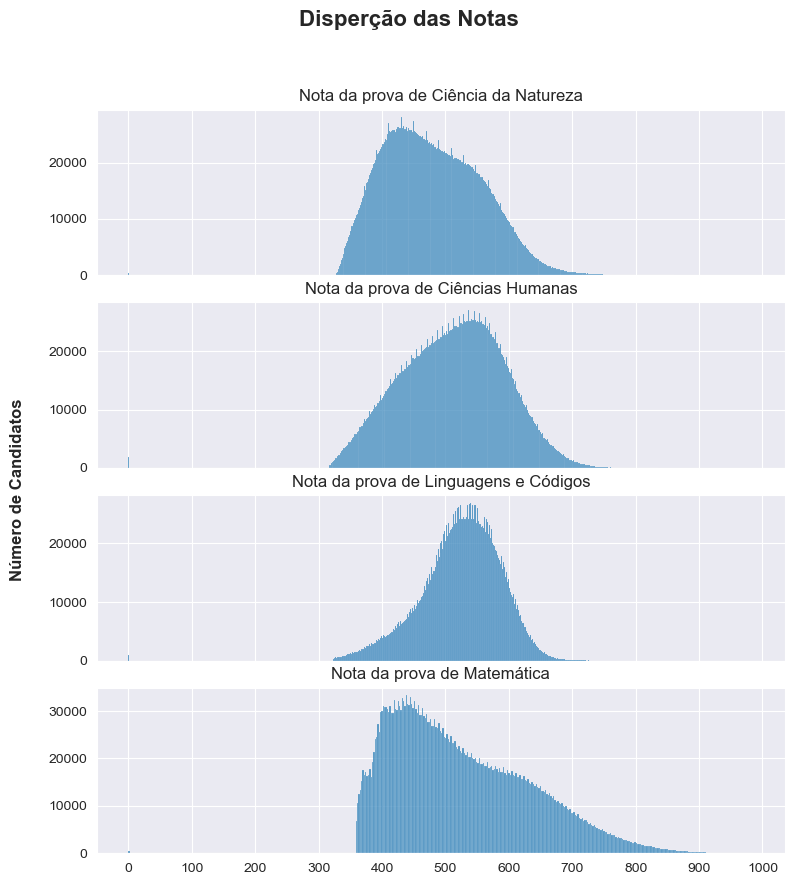

In [22]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(4, 1, sharex = True, figsize = (8, 8))
plt.tight_layout()
plt.subplots_adjust(left = 0.11) 

labels = ['Nota da prova de Ciência da Natureza',
          'Nota da prova de Ciências Humanas',
          'Nota da prova de Linguagens e Códigos',
          'Nota da prova de Matemática']

for i in range (4):
    coluna_1 = colunas_notas[i]
    sns.histplot(data = df_enem[coluna_1],
                 ax = graficos[i])
    graficos[i].set_xlabel('')
    graficos[i].set_ylabel('')
    graficos[i].set_title(labels[i])
    graficos[i].set_yticks(np.arange(0, df_enem[coluna_1].value_counts().max() + 1000),
                           minor = True)
    graficos[i].set_xticks(np.arange(0, 1100, 100))
    
figura.suptitle('Disperção das Notas',
                y = 1.1, fontsize = 16,
               fontweight = 'bold')
figura.text(0.001, 0.5,'Número de Candidatos',
            va = 'center', rotation = 'vertical',
            fontsize = 12, fontweight = 'bold')

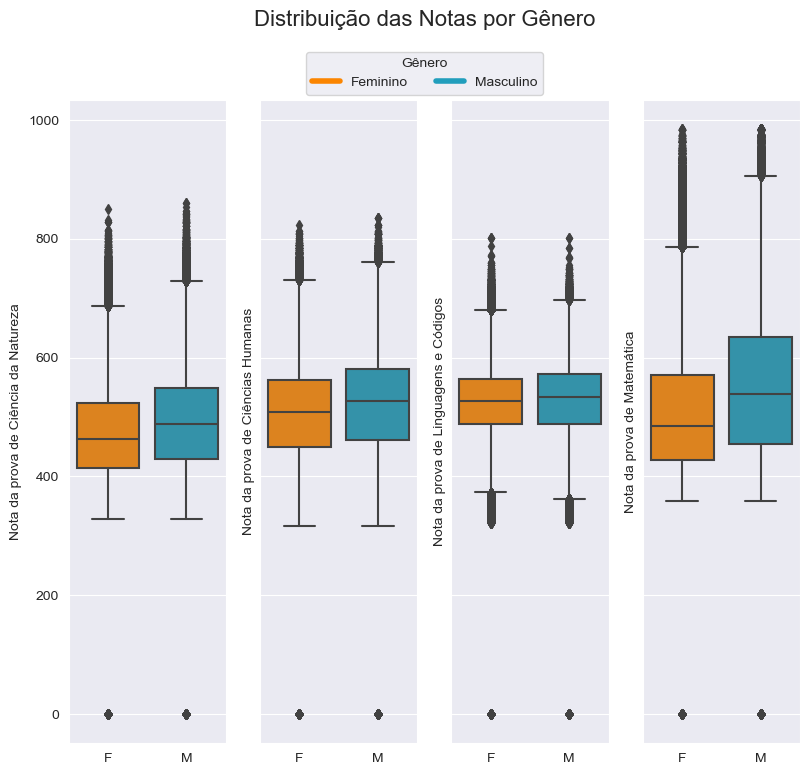

In [23]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots (1, 4, sharey = True, figsize = (8, 7))
plt.tight_layout()
paleta = ['#fb8500', '#219ebc']

labels = ['Nota da prova de Ciência da Natureza',
          'Nota da prova de Ciências Humanas',
          'Nota da prova de Linguagens e Códigos',
          'Nota da prova de Matemática']

for i in range(4):
    coluna_1 = colunas_notas[i]
    sns.boxplot(data = df_enem, y = coluna_1,
                ax = graficos[i], x = 'TP_SEXO',
               palette = paleta)
    graficos[i].set_ylabel(labels[i])
    graficos[i].set_xlabel("")
    
legenda = [
    Line2D([0], [0], 
           color = '#fb8500',
           lw = 4,
           label = 'Feminino'),  
    Line2D([0], [0],
           color = '#219ebc',
           lw = 4,
           label = 'Masculino')  
]

figura.legend(handles = legenda,
              title = 'Gênero',
              loc = 'upper center',
              bbox_to_anchor = (0.5, 1.05),
              ncol = 2)

figura.suptitle('Distribuição das Notas por Gênero', y = 1.1, fontsize = 16)

plt.show()

Text(0.5, 1.1, 'Disperção das Notas de Redação')

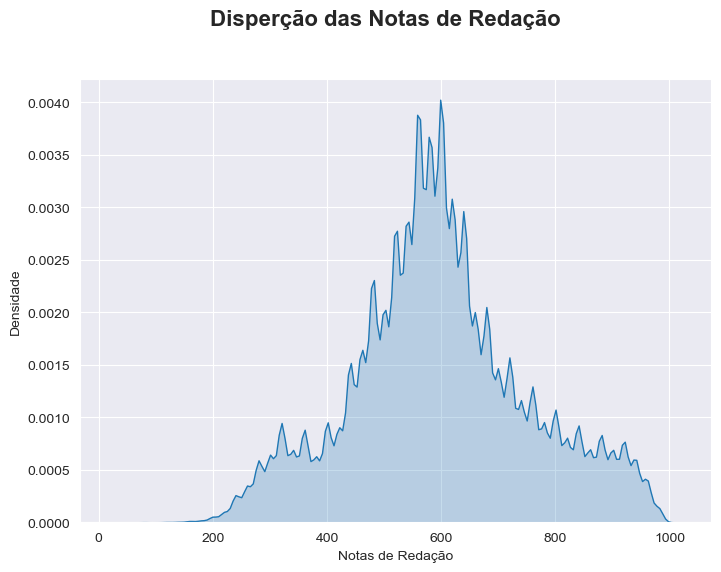

In [24]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, sharex = True, figsize = (7, 5))
plt.tight_layout()

sns.kdeplot(data = df_enem['NU_NOTA_REDACAO'],
             ax = graficos, fill = all)

graficos.set_xlabel('Notas de Redação')
graficos.set_ylabel('Densidade')
figura.suptitle('Disperção das Notas de Redação',
                y = 1.1, fontsize = 16,
               fontweight = 'bold')

Text(0.5, 1.1, 'Distribuição das Notas de Redação por Gênero')

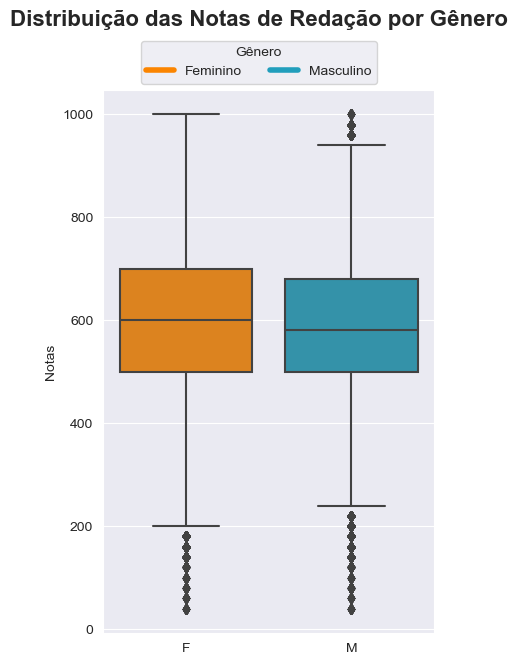

In [84]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, figsize = (4, 6))
plt.tight_layout()
paleta = ['#fb8500', '#219ebc']
 

sns.boxplot(data = df_enem, y = 'NU_NOTA_REDACAO',
             ax = graficos, x = 'TP_SEXO',
             palette = paleta)

legenda = [
    Line2D([0], [0], 
           color = '#fb8500',
           lw = 4,
           label = 'Feminino'),  
    Line2D([0], [0],
           color = '#219ebc',
           lw = 4,
           label = 'Masculino')  
]

figura.legend(handles = legenda,
              title = 'Gênero',
              loc = 'upper center',
              bbox_to_anchor = (0.5, 1.06),
              ncol = 2)
graficos.set_xlabel('')
graficos.set_ylabel('Notas')
figura.suptitle('Distribuição das Notas de Redação por Gênero',
                y = 1.1, fontsize = 16,
               fontweight = 'bold')

## <a> Analizando as Informações Demográficas </a>

In [26]:
print(df_enem['TP_SEXO'].value_counts(),
      df_enem['TP_SEXO'].value_counts(normalize = True) * 100)

TP_SEXO
F    2143138
M    1452979
Name: count, dtype: int64 TP_SEXO
F   59.60
M   40.40
Name: proportion, dtype: float64


Text(0, 0.5, 'Número de candidatos')

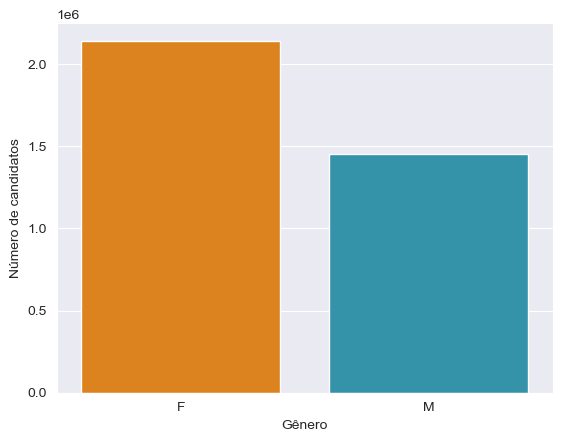

In [27]:
paleta = ['#fb8500', '#219ebc']
plot = sns.countplot(data = df_enem,
                     x = 'TP_SEXO',
                     palette = paleta)
plot.set_xlabel('Gênero')
plot.set_ylabel('Número de candidatos')

Text(0.5, 1.1, 'Disperção dos Candidatos por Idade')

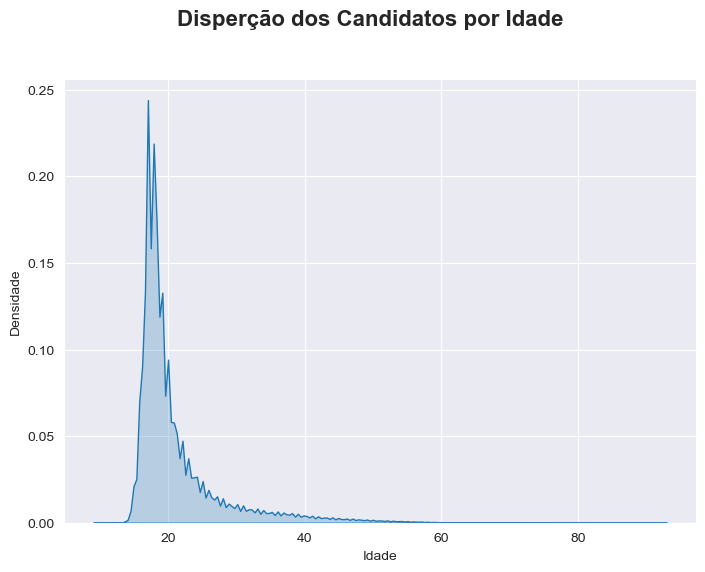

In [28]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, sharex = True, figsize = (7, 5))
plt.tight_layout()

sns.kdeplot(data = df_enem['NU_IDADE'],
             ax = graficos, fill = all)

graficos.set_xlabel('Idade')
graficos.set_ylabel('Densidade')
figura.suptitle('Disperção dos Candidatos por Idade',
                y = 1.1, fontsize = 16,
               fontweight = 'bold')

In [29]:
df_enem['NU_IDADE'].value_counts().sort_index().head(30)

NU_IDADE
10.00         5
11.00         8
12.00        28
13.00       191
14.00      3995
15.00     64698
16.00    271387
17.00    726227
18.00    691040
19.00    418348
20.00    277687
21.00    186465
22.00    143676
23.00    111513
24.00     89884
25.00     71412
26.00     58418
27.00     48721
28.00     41755
29.00     35494
30.00     33031
31.00     29902
32.00     26379
33.00     24649
34.00     22380
35.00     20248
36.00     19280
37.00     18538
38.00     17455
39.00     15342
Name: count, dtype: int64

TP_COR_RACA
0      70673
1    1347877
2     438407
3    1636663
4      82301
5      20196
Name: count, dtype: int64


'\n0 Não declarado\n1 Branca\n2 Preta\n3 Parda\n4 Amarela\n5 Indígena \n'

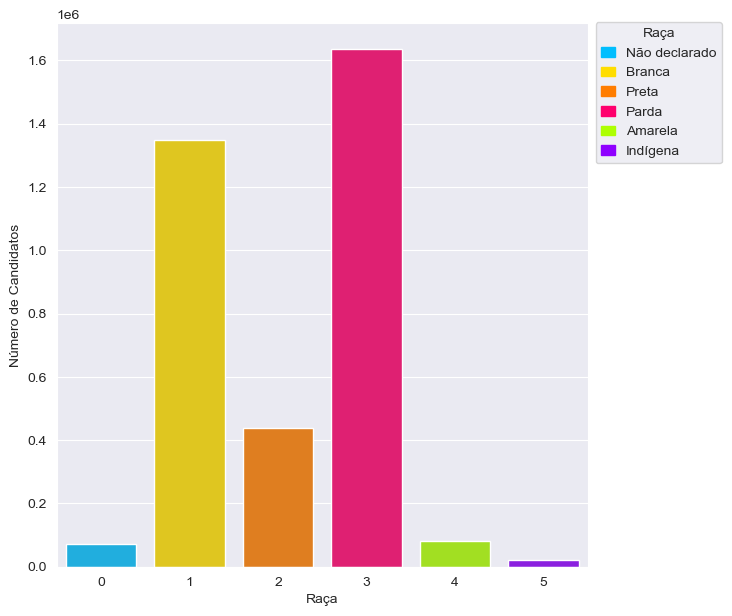

In [119]:
'''
0 Não declarado
1 Branca
2 Preta
3 Parda
4 Amarela
5 Indígena 
'''
print(df_enem['TP_COR_RACA'].value_counts().sort_index())
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, figsize = (6, 6))
plt.subplots_adjust(bottom = 0.10) 
plt.tight_layout()

paleta = ['#01befe', '#ffdd00', '#ff7d00', '#ff006d', '#adff02', '#8f00ff']
legenda = [
    'Não declarado',
    'Branca',
    'Preta',
    'Parda',
    'Amarela',
    'Indígena' 
]

plot = sns.countplot(data = df_enem,
                     x = 'TP_COR_RACA',
                     ax = graficos,
                     palette = paleta)
plot.set_xlabel('Raça')
plot.set_ylabel('Número de Candidatos')

handles = [plt.Rectangle((0, 0), 1, 1,
                         color = paleta[i]) for i in range(len(legenda))]

figura.legend(handles,
              legenda,
              title = 'Raça',
              loc = 'upper left',
              bbox_to_anchor = (0.96, 0.98),
              handlelength = 1)

In [31]:
# Até que série seu pai, ou o homem responsável por você, estudou?
'''
A Nunca estudou.
B Não completou a 4ª série/5º ano do Ensino Fundamental.
C Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.
D Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.
E Completou o Ensino Médio, mas não completou a Faculdade.
F Completou a Faculdade, mas não completou a Pós-graduação.
G Completou a Pós-graduação.
H Não sei.
'''
df_enem['Q001'].value_counts().sort_index()

Q001
A    175466
B    725030
C    499651
D    421445
E    985295
F    304799
G    191529
H    292902
Name: count, dtype: int64

In [32]:
# Até que série sua mãe, ou a mulher responsável por você, estudou?
'''
A Nunca estudou.
B Não completou a 4ª série/5º ano do Ensino Fundamental.
C Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.
D Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.
E Completou o Ensino Médio, mas não completou a Faculdade.
F Completou a Faculdade, mas não completou a Pós-graduação.
G Completou a Pós-graduação.
H Não sei.
'''
df_enem['Q002'].value_counts().sort_index()

Q002
A     113323
B     529214
C     455175
D     461104
E    1206143
F     410549
G     328972
H      91637
Name: count, dtype: int64

In [33]:
df_enem['pai_possui_superior'] = df_enem['Q001'].isin(['F', 'G'])
df_enem['mae_possui_superior'] = df_enem['Q002'].isin(['F', 'G'])
df_enem.head()

,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado,pai_possui_superior,mae_possui_superior
numero_candidato,,,,,,,,,,,,,,,,,
1,25.00,F,1,1,483.80,503.60,537.30,392.00,460.00,C,E,E,B,B,False,False,False
2,22.00,F,1,1,513.60,575.50,570.70,677.00,860.00,E,E,G,B,B,False,False,False
3,37.00,M,2,1,563.70,644.90,564.20,675.30,800.00,B,B,E,B,B,False,False,False
4,22.00,F,3,1,484.60,488.40,507.20,594.70,600.00,E,B,B,A,A,False,False,False
5,17.00,M,1,2,543.90,548.10,502.50,480.70,400.00,E,E,F,B,B,False,False,False


pai_possui_superior
False   86.20
True    13.80
Name: proportion, dtype: float64

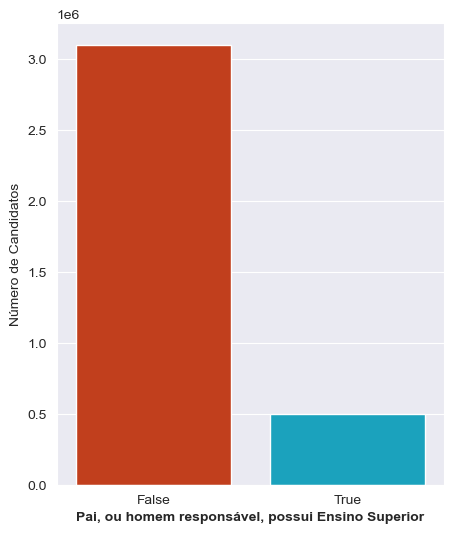

In [36]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, figsize = (5, 6))
paleta = ['#dc2f02', '#00b4d8']

plot = sns.countplot(data = df_enem,
                     x = 'pai_possui_superior',
                     ax = graficos,
                     palette = paleta)
plot.set_xlabel('Pai, ou homem responsável, possui Ensino Superior',
                fontweight = 'bold')
plot.set_ylabel('Número de Candidatos')


df_enem['pai_possui_superior'].value_counts(normalize = True) * 100 

mae_possui_superior
False   79.44
True    20.56
Name: proportion, dtype: float64

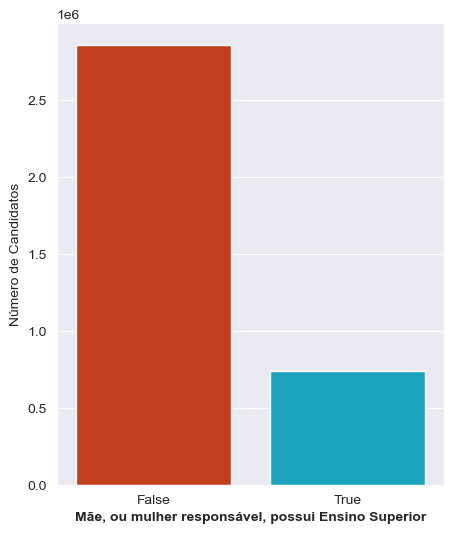

In [38]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, figsize = (5, 6))
paleta = ['#dc2f02', '#00b4d8']

plot = sns.countplot(data = df_enem,
                     x = 'mae_possui_superior',
                     ax = graficos,
                     palette = paleta)
plot.set_xlabel('Mãe, ou mulher responsável, possui Ensino Superior',
                fontweight = 'bold')
plot.set_ylabel('Número de Candidatos')


df_enem['mae_possui_superior'].value_counts(normalize = True) * 100 

In [40]:
'''
Qual é a renda mensal de sua família? (Some a sua renda com a dos seus familiares.
A Nenhuma renda.
B Até R$ 998,00.
C De R$ 998,01 até R$ 1.497,00.
D De R$ 1.497,01 até R$ 1.996,00.
E De R$ 1.996,01 até R$ 2.495,00.
F De R$ 2.495,01 até R$ 2.994,00.
G De R$ 2.994,01 até R$ 3.992,00.
H De R$ 3.992,01 até R$ 4.990,00.
I De R$ 4.990,01 até R$ 5.988,00.
J De R$ 5.988,01 até R$ 6.986,00.
K De R$ 6.986,01 até R$ 7.984,00.
L De R$ 7.984,01 até R$ 8.982,00.
M De R$ 8.982,01 até R$ 9.980,00.
N De R$ 9.980,01 até R$ 11.976,00.
O De R$ 11.976,01 até R$ 14.970,00.
P De R$ 14.970,01 até R$ 19.960,00.
Q Mais de R$ 19.960,00.
'''
dicionario_renda = dict()

for i, letra in enumerate(ascii_uppercase):
    if i == 17:
        break
    dicionario_renda[letra] = i
    
df_enem['renda_familiar'] = df_enem['Q006'].map(dicionario_renda)

df_enem.head()

,NU_IDADE,TP_SEXO,TP_COR_RACA,TP_ESCOLA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q006,Q024,Q025,atendimento_especializado,pai_possui_superior,mae_possui_superior,renda_familiar
numero_candidato,,,,,,,,,,,,,,,,,,
1,25.00,F,1,1,483.80,503.60,537.30,392.00,460.00,C,E,E,B,B,False,False,False,4
2,22.00,F,1,1,513.60,575.50,570.70,677.00,860.00,E,E,G,B,B,False,False,False,6
3,37.00,M,2,1,563.70,644.90,564.20,675.30,800.00,B,B,E,B,B,False,False,False,4
4,22.00,F,3,1,484.60,488.40,507.20,594.70,600.00,E,B,B,A,A,False,False,False,1
5,17.00,M,1,2,543.90,548.10,502.50,480.70,400.00,E,E,F,B,B,False,False,False,5


Text(415.34722222222223, 0.5, 'Número de Candidatos')

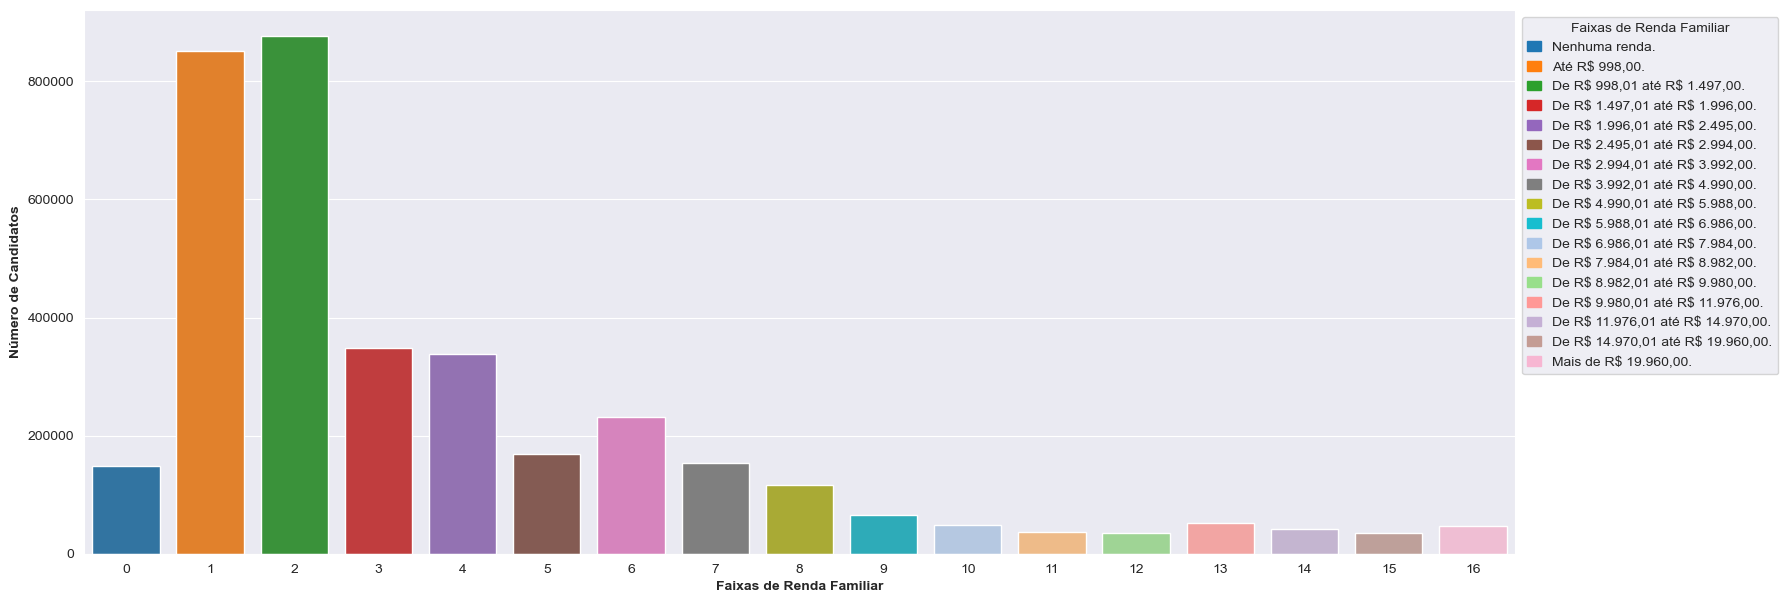

In [58]:
sns.set_style("darkgrid")
figura, graficos = plt.subplots(1, 1, figsize = (15, 6))
paleta = ['#1f77b4', '#ff7f0e', '#2ca02c',
          '#d62728', '#9467bd', '#8c564b',
          '#e377c2', '#7f7f7f', '#bcbd22',
          '#17becf', '#aec7e8', '#ffbb78',
          '#98df8a', '#ff9896', '#c5b0d5',
          '#c49c94', '#f7b6d2']
plt.subplots_adjust(left = 0.30)
plt.tight_layout()

faixas_renda = [
    "Nenhuma renda.",
    "Até R$ 998,00.",
    "De R$ 998,01 até R\$ 1.497,00.",
    "De R$ 1.497,01 até R\$ 1.996,00.",
    "De R$ 1.996,01 até R\$ 2.495,00.",
    "De R$ 2.495,01 até R\$ 2.994,00.",
    "De R$ 2.994,01 até R\$ 3.992,00.",
    "De R$ 3.992,01 até R\$ 4.990,00.",
    "De R$ 4.990,01 até R\$ 5.988,00.",
    "De R$ 5.988,01 até R\$ 6.986,00.",
    "De R$ 6.986,01 até R\$ 7.984,00.",
    "De R$ 7.984,01 até R\$ 8.982,00.",
    "De R$ 8.982,01 até R\$ 9.980,00.",
    "De R$ 9.980,01 até R\$ 11.976,00.",
    "De R$ 11.976,01 até R\$ 14.970,00.",
    "De R$ 14.970,01 até R\$ 19.960,00.",
    "Mais de R\$ 19.960,00."
]

handles = [plt.Rectangle((0, 0), 1, 1,
                         color = paleta[i]) for i in range(len(faixas_renda))]
graficos.legend(handles,
                faixas_renda,
                title = "Faixas de Renda Familiar",
                bbox_to_anchor = (1, 1), loc = 'upper left',
                handlelength = 1)

plot = sns.countplot(data = df_enem,
                     x = 'renda_familiar',
                     ax = graficos,
                     palette = paleta)
plot.set_xlabel('Faixas de Renda Familiar',
                fontweight = 'bold')
plot.set_ylabel('Número de Candidatos', 
               fontweight = 'bold')

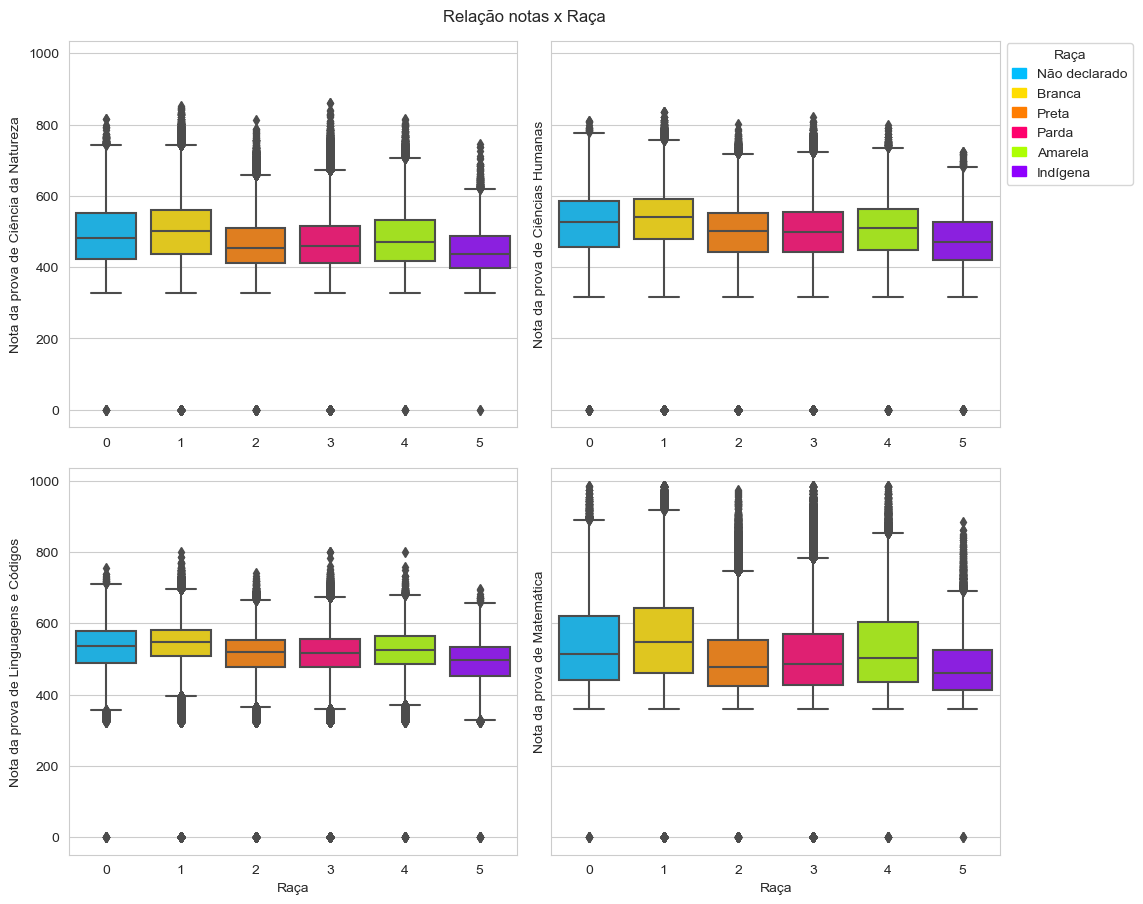

In [117]:
sns.set_style("whitegrid")
figura, graficos = plt.subplots(2, 2,
                                sharey = True,
                                figsize = (10, 9))
figura.suptitle ('Relação notas x Raça')
paleta = ['#01befe', '#ffdd00', '#ff7d00', '#ff006d', '#adff02', '#8f00ff']
plt.tight_layout()

labels = ['Nota da prova de Ciência da Natureza',
          'Nota da prova de Ciências Humanas',
          'Nota da prova de Linguagens e Códigos',
          'Nota da prova de Matemática']

legenda = [
    'Não declarado',
    'Branca',
    'Preta',
    'Parda',
    'Amarela',
    'Indígena' 
]

for i in range(2):
    coluna_1 = colunas_notas[i*2]
    coluna_2 = colunas_notas[i*2+1]
    sns.boxplot(data = df_enem,
                y = coluna_1,
                x = 'TP_COR_RACA',
                ax = graficos[i][0],
                palette = paleta)
    sns.boxplot(data = df_enem,
                y = coluna_2,
                x = 'TP_COR_RACA',
                ax = graficos[i][1],
                palette = paleta)
    graficos[i][0].set_ylabel(labels[i*2])
    graficos[i][1].set_ylabel(labels[i*2+1])
graficos[1][0].set_xlabel('Raça')
graficos[1][1].set_xlabel('Raça')

handles = [plt.Rectangle((0, 0), 1, 1,
                         color = paleta[i]) for i in range(len(legenda))]
figura.legend(handles,
                legenda,
                title = "Raça",
                bbox_to_anchor = (0.975, 0.95),
                loc = 'upper left',
                handlelength = 1)